In [2]:
from torchvision.datasets import CelebA

dataset = CelebA(root='data', split='train', download=True)

# Understanding the shape of the data

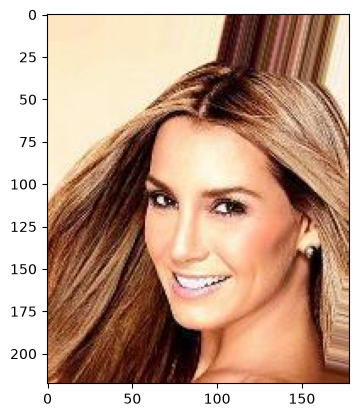

Attributes :  tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1])


In [ ]:
import matplotlib.pyplot as plt

img, target = dataset[0]

plt.imshow(img)
plt.axis('o')
plt.show()

print("Attributes : ", target)

# Defining the Model

### Generator : 
Input: a latent z of dimension noise_dim (assume gaussian distribution) \
Output : A proposed image

### Discriminator
Input: a proposed image, namely the output G(z) \
Output : A binary classification label 
* '1' : The discriminator predicts that the image comes from distribution pdata (image is part of training set) 
* '0' : The dicrimimator predicts that the image comes from distribution pG (image was generated by Generator) 

### Goal 
The minimax game has achieved optimality when: 

$pG(x) = pData(x)$ (Optimal generator for optimal D) \
$DG(x) = \frac{pdata(x)}{pdata(x) + pG(x)} = 0.5$ (Discriminator is guessing)

In [ ]:
import torch.nn as nn 

class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_height=218, img_width=178, img_channels=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            nn.Linear(self.latent_dim, 256), 
            nn.BatchNorm1d(256),
            nn.ReLU(), 

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            # Flatten to image dimensions
            # Tanh b/c pixel values are normalized between -1 and 1
            nn.Linear(512, img_height * img_width * img_channels),
            nn.Tanh(), 

            # [B, H * W * C] -> [B, C, H, W]
            nn.Unflatten(-1, (img_channels, img_height, img_width))
        )

    def forward(self, z):
        x = self.model(z)
        return x

In [ ]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_height=218, img_width=178, img_channels=3):
        super().__init__()

        # P(Y=1|x) = D(x) = sigmoid(f(x))
        self.model = nn.Sequential(
            nn.Flatten(start_dim=1), 

            nn.Linear(img_height * img_width * img_channels, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.model(x)
        return y

In [ ]:
import torch

LATENT_DIM = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = Generator(latent_dim=LATENT_DIM)
discriminator = Discriminator()



